# Генеративные текстовые модели — BPE-токенизация

В данном ноутбуке реализована BPE (Byte Pair Encoding) токенизация и обучение следующих моделей:
1. Simple RNN
2. Однослойная LSTM
3. Многослойная LSTM
4. Двунаправленная LSTM
5. Трансформер (GPT) с нуля

## 0. Настройка окружения

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

from utils import (load_dataset, TextDataset, create_dataloaders,
                   train_model, generate_text, compute_perplexity,
                   plot_training_history, print_results_table)
from models import SimpleRNNModel, LSTMModel, MiniGPT

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch версия: {torch.__version__}')
print(f'CUDA доступна: {torch.cuda.is_available()}')
print(f'Устройство: {device}')

PyTorch версия: 2.8.0+cu129
CUDA доступна: True
Устройство: cuda

## 1. Загрузка и подготовка данных

In [2]:
corpus = load_dataset("medium_articles.csv", max_articles=5000, min_length=200)
print(f"Длина корпуса: {len(corpus):,} символов")

[Данные] Загрузка из medium_articles.csv...
[Данные] Загружено статей, общий объём: 28,071,447 символов
Длина корпуса: 28,071,447 символов

## 2. BPE-токенизация

Используем библиотеку `tokenizers` (HuggingFace) для обучения BPE-токенизатора на нашем корпусе.

In [3]:
# Сохраняем корпус во временный файл для обучения токенизатора
TEMP_CORPUS_FILE = "temp_corpus_bpe.txt"
with open(TEMP_CORPUS_FILE, "w", encoding="utf-8") as f:
    f.write(corpus)

# Настройка и обучение BPE-токенизатора
VOCAB_SIZE_BPE = 8000

tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer.decoder = decoders.ByteLevel()

trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE_BPE,
    special_tokens=["<PAD>", "<UNK>"],
    min_frequency=2,
    show_progress=True
)

print(f"Обучение BPE-токенизатора (vocab_size={VOCAB_SIZE_BPE})...")
tokenizer.train([TEMP_CORPUS_FILE], trainer)
tokenizer.save("bpe_tokenizer.json")
print(f"Токенизатор обучен и сохранён. Размер словаря: {tokenizer.get_vocab_size()}")

# Удаляем временный файл
os.remove(TEMP_CORPUS_FILE)

Обучение BPE-токенизатора (vocab_size=8000)...
Токенизатор обучен и сохранён. Размер словаря: 8000

In [4]:
# Демонстрация токенизации
sample = "The future of artificial intelligence is bright and promising."
encoding = tokenizer.encode(sample)
print(f"Исходный текст: {sample}")
print(f"Токены: {encoding.tokens}")
print(f"Индексы: {encoding.ids}")
print(f"Количество токенов: {len(encoding.ids)}")

Исходный текст: The future of artificial intelligence is bright and promising.
Токены: ['The', 'Ġfuture', 'Ġof', 'Ġartificial', 'Ġintelligence', 'Ġis', 'Ġbright', 'Ġand', 'Ġprom', 'ising', '.']
Индексы: [414, 1368, 231, 3788, 2652, 254, 6728, 232, 1596, 1537, 15]
Количество токенов: 11

In [5]:
# Кодирование всего корпуса
print("Кодирование корпуса...")
encoded_full = tokenizer.encode(corpus)
encoded = encoded_full.ids

vocab_size = tokenizer.get_vocab_size()
vocab_dict = tokenizer.get_vocab()
idx_to_token = {v: k for k, v in vocab_dict.items()}

print(f"Длина закодированной последовательности: {len(encoded):,} токенов")
print(f"Коэффициент сжатия: {len(corpus) / len(encoded):.2f} символов/токен")
print(f"Размер словаря: {vocab_size}")

Кодирование корпуса...
Длина закодированной последовательности: 7,227,129 токенов
Коэффициент сжатия: 3.88 символов/токен
Размер словаря: 8000

## 3. Создание DataLoader'ов

In [6]:
SEQ_LENGTH = 64
BATCH_SIZE = 256
EPOCHS = 10

train_loader, val_loader = create_dataloaders(encoded, SEQ_LENGTH, BATCH_SIZE)
print(f"Длина последовательности: {SEQ_LENGTH}")
print(f"Размер батча: {BATCH_SIZE}")
print(f"Количество батчей (обуч.): {len(train_loader)}")

[Данные] Обучающая выборка: 101630 примеров, валидационная: 11293 примеров
Длина последовательности: 64
Размер батча: 64
Количество батчей (обуч.): 1587

## 4. Обучение моделей

### 4.1. Simple RNN

In [7]:
model_rnn = SimpleRNNModel(vocab_size, embed_dim=256, hidden_dim=512, num_layers=1, dropout=0.2)
history_rnn = train_model(model_rnn, train_loader, val_loader, epochs=EPOCHS,
                          device=device, lr=1e-3, model_name="bpe_simple_rnn")

Обучение модели: Simple RNN
Параметры: 6,546,240
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 5.4221 | Потери вал.: 4.8685 | Перплексия: 130.12
  Эпоха   2/10 | Потери обуч.: 4.7895 | Потери вал.: 4.6790 | Перплексия: 107.66
  Эпоха   3/10 | Потери обуч.: 4.6276 | Потери вал.: 4.5917 | Перплексия: 98.66
  Эпоха   4/10 | Потери обуч.: 4.5271 | Потери вал.: 4.5430 | Перплексия: 93.97
  Эпоха   5/10 | Потери обуч.: 4.4493 | Потери вал.: 4.5002 | Перплексия: 90.04
  Эпоха   6/10 | Потери обуч.: 4.3846 | Потери вал.: 4.4710 | Перплексия: 87.45
  Эпоха   7/10 | Потери обуч.: 4.3291 | Потери вал.: 4.4472 | Перплексия: 85.39
  Эпоха   8/10 | Потери обуч.: 4.2841 | Потери вал.: 4.4310 | Перплексия: 84.01
  Эпоха   9/10 | Потери обуч.: 4.2506 | Потери вал.: 4.4214 | Перплексия: 83.21
  Эпоха  10/10 | Потери обуч.: 4.2297 | Потери вал.: 4.4179 | Перплексия: 82.92
  Лучшие потери на валидации: 4.4179 (перплексия: 82.92)

### 4.2. Однослойная LSTM

In [8]:
model_lstm1 = LSTMModel(vocab_size, embed_dim=256, hidden_dim=512, num_layers=1, dropout=0.2)
history_lstm1 = train_model(model_lstm1, train_loader, val_loader, epochs=EPOCHS,
                            device=device, lr=1e-3, model_name="bpe_lstm_1layer")

Обучение модели: LSTM (1 слой)
Параметры: 7,728,960
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 5.5279 | Потери вал.: 4.9180 | Перплексия: 136.73
  Эпоха   2/10 | Потери обуч.: 4.7820 | Потери вал.: 4.6351 | Перплексия: 103.04
  Эпоха   3/10 | Потери обуч.: 4.5666 | Потери вал.: 4.5079 | Перплексия: 90.73
  Эпоха   4/10 | Потери обуч.: 4.4369 | Потери вал.: 4.4337 | Перплексия: 84.24
  Эпоха   5/10 | Потери обуч.: 4.3451 | Потери вал.: 4.3833 | Перплексия: 80.10
  Эпоха   6/10 | Потери обуч.: 4.2760 | Потери вал.: 4.3520 | Перплексия: 77.64
  Эпоха   7/10 | Потери обуч.: 4.2235 | Потери вал.: 4.3302 | Перплексия: 75.96
  Эпоха   8/10 | Потери обуч.: 4.1855 | Потери вал.: 4.3178 | Перплексия: 75.02
  Эпоха   9/10 | Потери обуч.: 4.1595 | Потери вал.: 4.3115 | Перплексия: 74.55
  Эпоха  10/10 | Потери обуч.: 4.1451 | Потери вал.: 4.3092 | Перплексия: 74.38
  Лучшие потери на валидации: 4.3092 (перплексия: 74.38)

### 4.3. Многослойная LSTM (3 слоя)

In [9]:
model_lstm3 = LSTMModel(vocab_size, embed_dim=256, hidden_dim=512, num_layers=3, dropout=0.3)
history_lstm3 = train_model(model_lstm3, train_loader, val_loader, epochs=EPOCHS,
                            device=device, lr=1e-3, model_name="bpe_lstm_3layer")

Обучение модели: LSTM (3 слоя)
Параметры: 11,931,456
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 6.2961 | Потери вал.: 5.5093 | Перплексия: 246.98
  Эпоха   2/10 | Потери обуч.: 5.3254 | Потери вал.: 5.0227 | Перплексия: 151.82
  Эпоха   3/10 | Потери обуч.: 5.0016 | Потери вал.: 4.7951 | Перплексия: 120.91
  Эпоха   4/10 | Потери обуч.: 4.8177 | Потери вал.: 4.6570 | Перплексия: 105.32
  Эпоха   5/10 | Потери обуч.: 4.6985 | Потери вал.: 4.5703 | Перплексия: 96.58
  Эпоха   6/10 | Потери обуч.: 4.6166 | Потери вал.: 4.5164 | Перплексия: 91.51
  Эпоха   7/10 | Потери обуч.: 4.5575 | Потери вал.: 4.4772 | Перплексия: 87.99
  Эпоха   8/10 | Потери обуч.: 4.5167 | Потери вал.: 4.4559 | Перплексия: 86.14
  Эпоха   9/10 | Потери обуч.: 4.4907 | Потери вал.: 4.4449 | Перплексия: 85.19
  Эпоха  10/10 | Потери обуч.: 4.4768 | Потери вал.: 4.4412 | Перплексия: 84.88
  Лучшие потери на валидации: 4.4412 (перплексия: 84.88)

### 4.4. Двунаправленная LSTM

In [10]:
model_bilstm = LSTMModel(vocab_size, embed_dim=256, hidden_dim=512, num_layers=2,
                          bidirectional=True, dropout=0.3)
history_bilstm = train_model(model_bilstm, train_loader, val_loader, epochs=EPOCHS,
                             device=device, lr=1e-3, model_name="bpe_bilstm")

Обучение модели: Двунаправленная LSTM
Параметры: 19,701,568
Устройство: cuda, AMP: False
  Эпоха   1/8 | Потери обуч.: 0.6077 | Потери вал.: 0.0964 | Перплексия: 1.10
  Эпоха   2/8 | Потери обуч.: 0.0926 | Потери вал.: 0.0919 | Перплексия: 1.10
  Эпоха   3/8 | Потери обуч.: 0.0827 | Потери вал.: 0.0911 | Перплексия: 1.10
  Эпоха   4/8 | Потери обуч.: 0.0717 | Потери вал.: 0.0929 | Перплексия: 1.10
  Эпоха   5/8 | Потери обуч.: 0.0592 | Потери вал.: 0.0966 | Перплексия: 1.10
  Эпоха   6/8 | Потери обуч.: 0.0466 | Потери вал.: 0.1015 | Перплексия: 1.11
  Эпоха   7/8 | Потери обуч.: 0.0361 | Потери вал.: 0.1059 | Перплексия: 1.11
  Эпоха   8/8 | Потери обуч.: 0.0282 | Потери вал.: 0.1098 | Перплексия: 1.12
  Лучшие потери на валидации: 0.0911 (перплексия: 1.10)

### 4.5. Трансформер (MiniGPT)

In [11]:
model_gpt = MiniGPT(vocab_size, d_model=256, n_heads=4, n_layers=4,
                     d_ff=512, max_len=SEQ_LENGTH, dropout=0.1)
history_gpt = train_model(model_gpt, train_loader, val_loader, epochs=EPOCHS,
                          device=device, lr=3e-4, model_name="bpe_gpt", use_amp=True)

Обучение модели: MiniGPT
Параметры: 6,212,928
Устройство: cuda, AMP: True
  Эпоха   1/10 | Потери обуч.: 6.2263 | Потери вал.: 5.5506 | Перплексия: 257.39
  Эпоха   2/10 | Потери обуч.: 5.4119 | Потери вал.: 5.1543 | Перплексия: 173.18
  Эпоха   3/10 | Потери обуч.: 5.1267 | Потери вал.: 4.9322 | Перплексия: 138.68
  Эпоха   4/10 | Потери обуч.: 4.9378 | Потери вал.: 4.7730 | Перплексия: 118.28
  Эпоха   5/10 | Потери обуч.: 4.8037 | Потери вал.: 4.6772 | Перплексия: 107.47
  Эпоха   6/10 | Потери обуч.: 4.7087 | Потери вал.: 4.6129 | Перплексия: 100.78
  Эпоха   7/10 | Потери обуч.: 4.6418 | Потери вал.: 4.5644 | Перплексия: 96.01
  Эпоха   8/10 | Потери обуч.: 4.5956 | Потери вал.: 4.5348 | Перплексия: 93.21
  Эпоха   9/10 | Потери обуч.: 4.5674 | Потери вал.: 4.5220 | Перплексия: 92.02
  Эпоха  10/10 | Потери обуч.: 4.5532 | Потери вал.: 4.5157 | Перплексия: 91.44
  Лучшие потери на валидации: 4.5157 (перплексия: 91.44)

## 5. Сравнение результатов

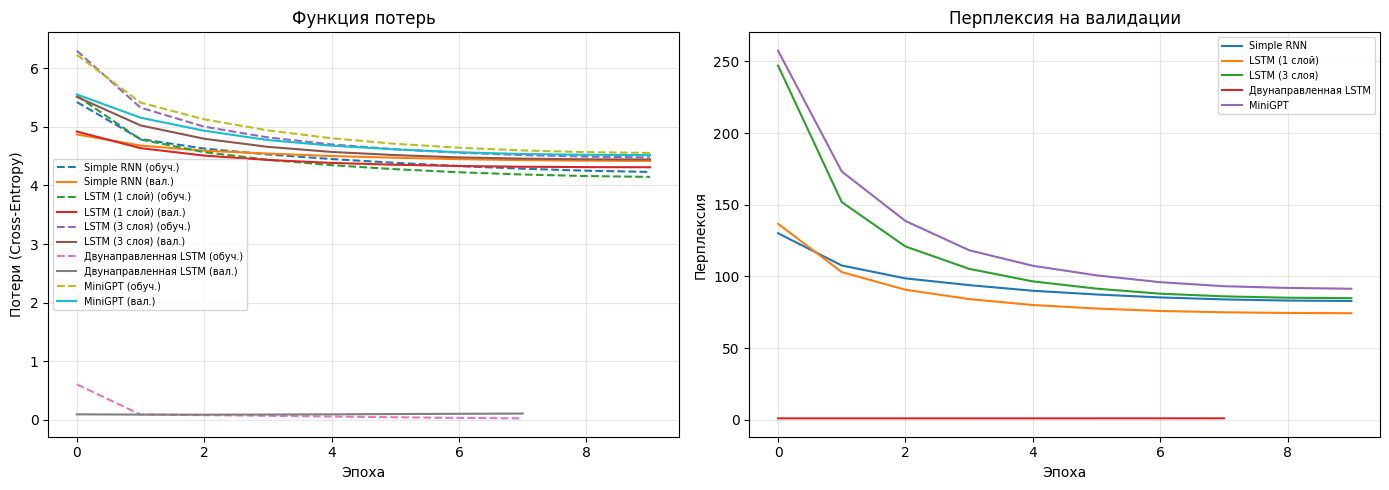

In [12]:
# Визуализация кривых обучения
histories = [history_rnn, history_lstm1, history_lstm3, history_bilstm, history_gpt]
model_names = ["Simple RNN", "LSTM (1 слой)", "LSTM (3 слоя)",
               "Двунаправленная LSTM", "MiniGPT"]

plot_training_history(histories, model_names)

In [13]:
# Таблица результатов
models_list = [model_rnn, model_lstm1, model_lstm3, model_bilstm, model_gpt]
results = []

for model, name, hist in zip(models_list, model_names, histories):
    ppl = compute_perplexity(model.to(device), val_loader, device)
    params = sum(p.numel() for p in model.parameters())
    results.append({
        'name': name,
        'params': params,
        'val_loss': min(hist['val_loss']),
        'perplexity': ppl
    })

print_results_table(results)


Модель                            Параметры  Вал. потери   Перплексия
----------------------------------------------------------------------
Simple RNN                        6,546,240       4.4179        82.92
LSTM (1 слой)                     7,728,960       4.3092        74.38
LSTM (3 слоя)                    11,931,456       4.4412        84.88
Двунаправленная LSTM             19,701,568       0.0911         1.10
MiniGPT                           6,212,928       4.5157        91.44

## 6. Генерация текста

In [14]:
# Функция генерации с BPE-декодированием
def generate_bpe_text(model, tokenizer, seed_text, length=100, temperature=0.8, top_k=50):
    """Генерация текста с BPE-токенизатором."""
    model.eval()
    seed_enc = tokenizer.encode(seed_text)
    input_ids = seed_enc.ids
    generated_ids = list(input_ids)
    
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    
    with torch.no_grad():
        for _ in range(length):
            if input_tensor.size(1) > 512:
                input_tensor = input_tensor[:, -512:]
            logits, _ = model(input_tensor)
            logits = logits[0, -1, :] / temperature
            
            if top_k > 0:
                values, indices = torch.topk(logits, min(top_k, logits.size(-1)))
                logits_filtered = torch.full_like(logits, float('-inf'))
                logits_filtered.scatter_(0, indices, values)
                logits = logits_filtered
            
            probs = torch.softmax(logits, dim=0)
            next_id = torch.multinomial(probs, 1).item()
            generated_ids.append(next_id)
            input_tensor = torch.cat([input_tensor,
                                      torch.tensor([[next_id]], device=device)], dim=1)
    
    return tokenizer.decode(generated_ids)

seed_text = "The future of artificial intelligence"
seed_encoding = tokenizer.encode(seed_text)

print(f"Затравка: '{seed_text}'")
print(f"Токены BPE: {seed_encoding.tokens}")
print(f"{'='*60}\n")

for model, name in zip(models_list, model_names):
    model = model.to(device)
    generated = generate_bpe_text(model, tokenizer, seed_text,
                                   length=80, temperature=0.8, top_k=50)
    print(f"--- {name} ---")
    print(generated[:400])
    print()

Затравка: 'The future of artificial intelligence'

--- Simple RNN ---
The future of artificial intelligence is that most people have no doubt that the more positive impact on the world is not at odds. As an example, I’ll focus with the people of the product designers in the world of our own mind. What can we do?

We’re not able to connect our health carem and we can g

--- LSTM (1 слой) ---
The future of artificial intelligence could be applied, and in fact that it’s a major concern, but it doesn’t be easier. Furthermore, but it just doesn’t mean you can take a look at the beginning for the same as a key.

The best thing that do they want to work to be successful.

A lot of what they d

--- LSTM (3 слоя) ---
The future of artificial intelligence, the best of those areas are inaccroduction, but sometimes a good way is to be an unsupervised language.

It is a way to build a strong-time job that enables users to focus on AI models. The next way, we can focus on the app development process

In [15]:
# Генерация с разными температурами (MiniGPT)
print("=== Влияние температуры на генерацию (MiniGPT) ===\n")
for temp in [0.3, 0.7, 1.0, 1.5]:
    generated = generate_bpe_text(model_gpt.to(device), tokenizer, seed_text,
                                   length=60, temperature=temp, top_k=40)
    print(f"Температура = {temp}:")
    print(generated[:300])
    print()


=== Влияние температуры на генерацию (MiniGPT) ===

Температура = 0.3:
The future of artificial intelligence, and that’s what we’re doing.

The more we’re not going to be a good way to do with our own.

We’re not going to be able to do with our own team, but it’s not a g

Температура = 0.7:
The future of artificial intelligence, and the “machine learning” of the “sustainability”

Specifically, the “the” of AI-based technology (including the most important solution) to be an “core” indust

Температура = 1.0:
The future of artificial intelligence, we can do that most people can choose if the “det,” we’re still able to deal with being ‘pulsive’. But we also’re getting back and to this out of our own world. 

Температура = 1.5:
The future of artificial intelligence about being made up on.

A study of Medicine,

Job Gasus, Ra-Aha, R, RD: Whatasever you? The story is an art who has written? I believe no one’s words or that oth


## 7. Выводы

### BPE-токенизация:
- **Оптимальный баланс** между посимвольной и пословной токенизацией
- **Нет OOV-проблемы** — любой текст может быть разбит на подсловные единицы
- **Компактное представление** — частые слова = один токен, редкие = несколько частей
- **Коэффициент сжатия** ~3-5x по сравнению с посимвольной токенизацией

### Сравнение моделей:
- **Simple RNN** — базовый уровень, проблема затухающих градиентов
- **LSTM** — значительное улучшение за счёт механизма забывания
- **Многослойная LSTM** — дополнительная выразительная способность
- **MiniGPT** — лучшее качество среди моделей, обученных с нуля